In [207]:
from libs import *
from utilities import *

from Bio import SeqIO
import re
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential, optimizers, losses, regularizers
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay



import warnings
warnings.filterwarnings("ignore")


In [208]:
from Bio import SeqIO
import pandas as pd
import numpy as np

# Hydrophobicity scale (Kyte-Doolittle)
hydro_scale = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

def extract_features(fasta_file):
    records = list(SeqIO.parse(fasta_file, "fasta"))
    features = []

    for record in records:
        seq = str(record.seq).upper()
        length = len(seq)

        # Amino acid composition
        counts = {aa: seq.count(aa) for aa in set(seq)}
        freq = {aa: counts.get(aa, 0) / length for aa in hydro_scale.keys()}

        # Hydrophobicity
        hydrophobicity = np.mean([hydro_scale.get(aa, 0) for aa in seq])

        # Cysteine count and pattern
        cysteine_count = seq.count('C')

        # Basic composition metrics
        gc_content = freq['G'] + freq['C']
        charge = freq['K'] + freq['R'] - freq['D'] - freq['E']
        aromaticity = freq['F'] + freq['Y'] + freq['W']

        # Motif checks (example: dibasic protease sites)
        has_dibasic_site = any(x in seq for x in ['KR', 'RR', 'RK'])

        features.append({
            'length': length,
            'hydrophobicity': hydrophobicity,
            'cysteine_count': cysteine_count,
            'gc_content': gc_content,
            'charge': charge,
            'aromaticity': aromaticity,
            'has_dibasic_site': int(has_dibasic_site),
            **freq
        })

    df = pd.DataFrame(features)
    return df

# Example usage
if __name__ == "__main__":
    df_new = extract_features("mango_data.fasta")
    df_new.to_csv("sspeptide_features.csv", index=False)


## Load data

In [209]:
df_new.head()

,length,hydrophobicity,cysteine_count,gc_content,charge,aromaticity,has_dibasic_site,A,R,N,...,L,K,M,F,P,S,T,W,Y,V
0,195,-0.830256,5,0.097436,0.076923,0.015385,1,0.066667,0.066667,0.025641,...,0.071795,0.138462,0.041026,0.015385,0.046154,0.087179,0.046154,0.000000,0.000000,0.061538
1,98,-0.502041,4,0.153061,-0.030612,0.091837,0,0.030612,0.061224,0.010204,...,0.061224,0.061224,0.020408,0.051020,0.030612,0.091837,0.030612,0.010204,0.030612,0.071429
2,196,-0.379082,5,0.142857,-0.025510,0.112245,1,0.030612,0.051020,0.035714,...,0.081633,0.056122,0.025510,0.061224,0.030612,0.086735,0.035714,0.010204,0.040816,0.056122
3,80,-1.118750,1,0.012500,-0.062500,0.075000,1,0.050000,0.062500,0.100000,...,0.087500,0.075000,0.037500,0.037500,0.012500,0.075000,0.012500,0.012500,0.025000,0.012500
4,177,-0.590395,3,0.045198,0.096045,0.084746,1,0.045198,0.039548,0.028249,...,0.084746,0.163842,0.050847,0.050847,0.045198,0.112994,0.050847,0.011299,0.022599,0.056497


In [210]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [211]:
df_new.columns.tolist()

['length',
 'hydrophobicity',
 'cysteine_count',
 'gc_content',
 'charge',
 'aromaticity',
 'has_dibasic_site',
 'A',
 'R',
 'N',
 'D',
 'C',
 'Q',
 'E',
 'G',
 'H',
 'I',
 'L',
 'K',
 'M',
 'F',
 'P',
 'S',
 'T',
 'W',
 'Y',
 'V']

In [212]:
numeric_cols = df_new.select_dtypes(include=[float, int]).columns.tolist()
scaler = StandardScaler()
df_standardized = df_new.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df_new[numeric_cols])

print("✅ Normalization done!")
print(df_standardized.head())

✅ Normalization done!
     length  hydrophobicity  cysteine_count  gc_content    charge  \
0  1.443114       -1.225879        0.726159    0.364855  1.021051   
1 -0.966081       -0.479074        0.365935    1.858607 -0.771797   
2  1.467951       -0.199298        0.726159    1.584589 -0.686735   
3 -1.413148       -1.882303       -0.714737   -1.915997 -1.303436   
4  0.996047       -0.680111        0.005711   -1.037938  1.339858   

   aromaticity  has_dibasic_site         A         R         N  ...         L  \
0    -2.027132          0.608035 -0.066382  0.424907 -0.809853  ... -0.638750   
1     0.247046         -1.644642 -1.217304  0.231287 -1.546049  ... -0.949969   
2     0.854116          0.608035 -1.217304 -0.131750 -0.329453  ... -0.349100   
3    -0.253786          0.608035 -0.598412  0.276667  2.736369  ... -0.176350   
4     0.036115          0.608035 -0.751709 -0.539910 -0.685496  ... -0.257442   

          K         M         F         P         S         T         W  \
0

In [213]:
label_mango,sequence_mango = readFastaFiles("mango_data.fasta")


In [214]:
len(sequence_mango)

5046

In [215]:
states = df_new.to_numpy().astype(np.float32)


In [216]:
states[0]

array([ 1.9500000e+02, -8.3025640e-01,  5.0000000e+00,  9.7435899e-02,
        7.6923080e-02,  1.5384615e-02,  1.0000000e+00,  6.6666670e-02,
        6.6666670e-02,  2.5641026e-02,  5.1282052e-02,  2.5641026e-02,
        5.1282052e-02,  7.6923080e-02,  7.1794875e-02,  2.0512821e-02,
        3.5897437e-02,  7.1794875e-02,  1.3846155e-01,  4.1025642e-02,
        1.5384615e-02,  4.6153847e-02,  8.7179489e-02,  4.6153847e-02,
        0.0000000e+00,  0.0000000e+00,  6.1538462e-02], dtype=float32)

In [217]:
states.shape

(5046, 27)

In [218]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [219]:
len(result_signalp_mango)

5046

In [220]:
unique, counts = np.unique(result_signalp_mango, return_counts=True)

In [221]:
#tape_data
mango_ebedding = np.load('sequence_mango.npy')

In [222]:
#ESM
embed2_mango = torch.load('embed2_mango.pt')

In [223]:
numpy_array_list = [tensor.numpy() for tensor in embed2_mango]
numpy_embed2_mango = np.array(numpy_array_list)

In [224]:
numpy_embed2_mango.shape

(5046, 1, 1280)

In [225]:
mango_ebedding2 = numpy_embed2_mango.reshape(numpy_embed2_mango.shape[0],numpy_embed2_mango.shape[2])


In [226]:
mango_ebedding2.shape

(5046, 1280)

In [227]:
len(embed2_mango)

5046

In [228]:
embedding_padded = np.concatenate((mango_ebedding, np.zeros((mango_ebedding.shape[0],16))), axis=1)
embedding2_padded = np.concatenate((mango_ebedding2, np.zeros((mango_ebedding2.shape[0],16))), axis=1)

In [229]:
shape_unit=28
embedding_images=np.reshape(embedding_padded,(embedding_padded.shape[0],shape_unit,shape_unit))

print(embedding_images.shape)

(5046, 28, 28)


In [230]:
shape_unit=36
embedding2_images=np.reshape(embedding2_padded,(embedding2_padded.shape[0],shape_unit,shape_unit))

print(embedding2_images.shape)

(5046, 36, 36)


In [231]:
#embedding_geotop = geotop_analysis(embedding_images)

In [232]:
#28*28
embedding_geotop = np.load("embedding_geotop_mango.npz")

In [233]:
#36*36
#embedding2_geotop = geotop_analysis(embedding2_images)

In [234]:
embedding2_geotop = np.load("embedding2_geotop_mango.npz")

In [235]:
embedding_geotop = [embedding_geotop['arr_'+str(i)] for i in range(len(embedding_geotop))]
embedding2_geotop = [embedding2_geotop['arr_'+str(i)] for i in range(len(embedding2_geotop))]

In [236]:
len(embedding2_geotop)

5046

# Trainning

### Tape and Geotop

In [237]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding_geotop)

In [238]:
dim = 1024
result = concate_embedding_geotop(mango_ebedding,dgms,dim)

In [239]:
#splitting the dataset
num_samples = len(result)
num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]

In [240]:
shape_unit=32
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data = np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [241]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [242]:
train_data_tape = np.expand_dims(train_data, -1)
test_data_tape = np.expand_dims(test_data, -1)

### ESM and Geotop

In [243]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding2_geotop)

In [244]:
dim = 1681
result = concate_embedding_geotop(mango_ebedding2,dgms,dim)

In [245]:
len(result)

5046

In [246]:
#splitting the dataset
#num_samples = len(result)
#num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]
#train_labels, test_labels = result_signalp_mango[:num_train_samples], result_signalp_mango[num_train_samples:]

In [247]:
shape_unit=41
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [248]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [249]:
train_data_esm = np.expand_dims(train_data, -1)
test_data_esm = np.expand_dims(test_data, -1)

In [250]:
len(test_data_esm)

1010

In [251]:
unique, counts = np.unique(y_train, return_counts=True)
print(np.asarray((unique, counts)).T)

[[   0 3790]
 [   1  246]]


In [252]:
unique, counts = np.unique(y_test, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  0 938]
 [  1  72]]


### Label

In [253]:
train_labels, test_labels = result_signalp_mango[:num_train_samples], result_signalp_mango[num_train_samples:]

In [254]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

### state

In [255]:
len(states)

5046

In [256]:
states_train, states_test = states[:num_train_samples], states[num_train_samples:]

In [257]:
num_train_samples

4036

In [258]:
state_dim = 9

In [259]:
states_test.shape

(1010, 27)

## Reinforcement Learning

In [260]:
# hyperparameters

In [294]:
n_pretrain_epochs = 50
batch_size_pretrain = 64
n_episodes = 20 #200
gamma = 0.99
policy_lr = 1e-4
value_lr = 1e-4
ent_coef = 0.02
print_every = 10
eps = 1e-8

In [262]:
#Policy network 

In [263]:
class PolicyNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.logit = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.logit(x)

    @tf.function
    def sample(self, x, training=False, eps=1e-8):
        logit = self(x, training=training)
        p = tf.sigmoid(tf.clip_by_value(logit, -5.0, 5.0))
        u = tf.random.uniform(tf.shape(p))
        action = tf.cast(u < p, tf.float32)
        logp = action * tf.math.log(p + eps) + (1.0 - action) * tf.math.log(1.0 - p + eps)
        entropy = -(p * tf.math.log(p + eps) + (1.0 - p) * tf.math.log(1.0 - p + eps))
        return action, tf.reshape(logp, (-1,)), tf.reshape(entropy, (-1,)), p

In [264]:
# Value network -> critic network

In [265]:
class ValueNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.v_out = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.v_out(x)

In [266]:
# losses and optmizers

In [295]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
policy_optimizer = optimizers.Adam(policy_lr, clipnorm=1.0)
value_optimizer = optimizers.Adam(value_lr, clipnorm=1.0)
value_loss_fn = tf.keras.losses.MeanSquaredError()

In [268]:
#trainning the classifier

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 41, 41, 8)         80        
                                                                 
 average_pooling2d_18 (Aver  (None, 20, 20, 8)         0         
 agePooling2D)                                                   
                                                                 
 conv2d_19 (Conv2D)          (None, 20, 20, 16)        1168      
                                                                 
 average_pooling2d_19 (Aver  (None, 10, 10, 16)        0         
 agePooling2D)                                                   
                                                                 
 conv2d_20 (Conv2D)          (None, 10, 10, 32)        4640      
                                                                 
 average_pooling2d_20 (Aver  (None, 5, 5, 32)         

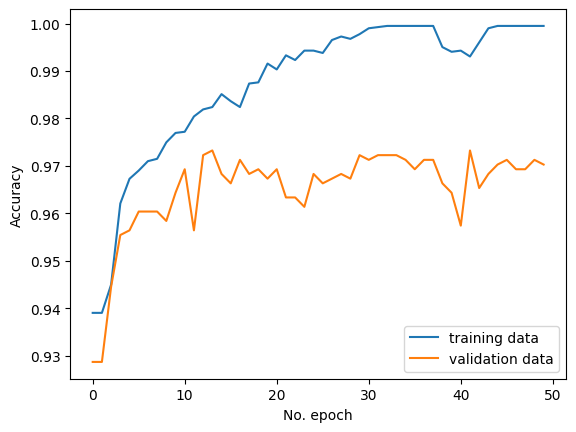

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 32, 32, 8)         80        
                                                                 
 average_pooling2d_21 (Aver  (None, 16, 16, 8)         0         
 agePooling2D)                                                   
                                                                 
 conv2d_22 (Conv2D)          (None, 16, 16, 16)        1168      
                                                                 
 average_pooling2d_22 (Aver  (None, 8, 8, 16)          0         
 agePooling2D)                                                   
                                                                 
 conv2d_23 (Conv2D)          (None, 8, 8, 32)          4640      
                                                                 
 average_pooling2d_23 (Aver  (None, 4, 4, 32)         

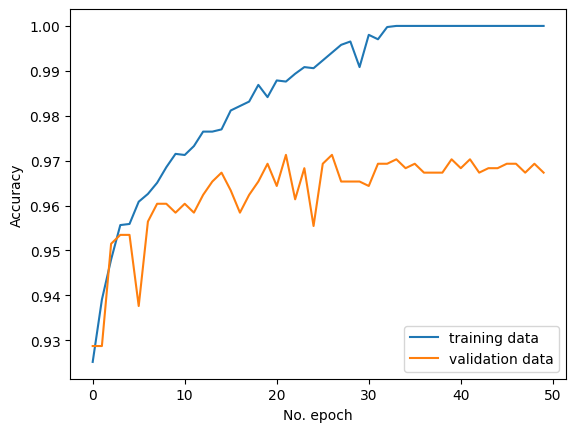

In [269]:
dim_ESM = train_data_esm.shape[1:3]
dim_TAPE = train_data_tape.shape[1:3]

model_trainning_saving(dim_ESM, n_pretrain_epochs, "classifier_ESM",
                                        train_data_esm, y_train,
                                        test_data_esm, y_test)

model_trainning_saving(dim_TAPE, n_pretrain_epochs, "classifier_TAPE",
                                         train_data_tape, y_train,
                                         test_data_tape, y_test)

In [288]:
#if the model is already trained, we can load them 
classifier_ESM = load_model("classifier_ESM.h5")
classifier_TAPE = load_model("classifier_TAPE.h5")

In [289]:
state_dim = states_train.shape[1]
policy = PolicyNetwork(state_dim)
value_net = ValueNetwork(state_dim)

In [290]:
if y_train.ndim == 1:
    y_train = y_train.reshape(-1, 1)

In [291]:
#RL loop

In [296]:
N = len(states_train)

for episode in range(1, n_episodes + 1):
    idx = np.random.permutation(N)
    log_probs_list, rewards_list, chosen_idxs, true_labels, preds_for_acc = [], [], [], [], []

    for i in idx:
        state_sample = tf.convert_to_tensor(states_train[i:i+1], dtype=tf.float32)
        action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
        log_probs_list.append(logp)

        # Get both classifier predictions
        logits_esm = classifier_ESM(tf.convert_to_tensor(train_data_esm[i:i+1], dtype=tf.float32), training=False)
        logits_tape = classifier_TAPE(tf.convert_to_tensor(train_data_tape[i:i+1], dtype=tf.float32), training=False)
        p_esm = logits_esm
        p_tape = logits_tape

        y_sample = y_train[i:i+1]
        if y_sample.ndim == 1:
            y_sample = y_sample.reshape(-1, 1)

        # Choose classifier based on policy action
        if int(action.numpy().flatten()[0]) == 0:
            chosen_p = p_esm
            other_p = p_tape
        else:
            chosen_p = p_tape
            other_p = p_esm

        loss_esm  = loss_fn(y_sample, p_esm)
        loss_tape = loss_fn(y_sample, p_tape)
        
        # Relative loss difference as reward
        if int(action.numpy().flatten()[0]) == 0:
            # Action 0 → chose ESM; reward positive if ESM better (lower loss)
            reward = tf.stop_gradient(loss_tape - loss_esm)
        else:
            # Action 1 → chose TAPE; reward positive if TAPE better
            reward = tf.stop_gradient(loss_esm - loss_tape)
        
        # Optional: normalize reward to [-1, 1] for stability
        reward = tf.clip_by_value(reward, -1.0, 1.0)

        rewards_list.append(tf.reshape(reward, (-1,)))
        preds_for_acc.append(tf.round(chosen_p).numpy().flatten()[0])
        chosen_idxs.append(int(action.numpy().flatten()[0]))
        true_labels.append(y_sample.flatten()[0])

    # --- Discounted rewards ---
    rewards_np = np.array([r.numpy()[0] for r in rewards_list])
    discounted, R = [], 0.0
    for r in reversed(rewards_np):
        R = r + gamma * R
        discounted.insert(0, R)
    discounted = tf.convert_to_tensor(discounted, dtype=tf.float32)
    discounted = (discounted - tf.reduce_mean(discounted)) / (tf.math.reduce_std(discounted) + 1e-8)

    states_batch = tf.convert_to_tensor(states_train[idx], dtype=tf.float32)
    actions_taken = tf.reshape(tf.convert_to_tensor(chosen_idxs, dtype=tf.float32), (-1, 1))

    # ===== Value Update =====
    with tf.GradientTape() as tape_v:
        values = tf.squeeze(value_net(states_batch, training=True), axis=-1)
        v_loss = value_loss_fn(discounted, values)
    v_grads = tape_v.gradient(v_loss, value_net.trainable_variables)
    value_optimizer.apply_gradients(zip(v_grads, value_net.trainable_variables))

    # ===== Policy Update =====
    with tf.GradientTape() as tape_pg:
        logits_batch = policy(states_batch, training=True)
        probs_batch = tf.sigmoid(tf.clip_by_value(logits_batch, -5.0, 5.0))
        logp_batch = actions_taken * tf.math.log(probs_batch + eps) + (1.0 - actions_taken) * tf.math.log(1.0 - probs_batch + eps)
        logp_batch = tf.reshape(logp_batch, (-1,))
        values = tf.squeeze(value_net(states_batch, training=False), axis=-1)
        advantages = discounted - tf.stop_gradient(values)
        advantages = (advantages - tf.reduce_mean(advantages)) / (tf.math.reduce_std(advantages) + 1e-8)
        entropy_batch = -(probs_batch * tf.math.log(probs_batch + eps) + (1.0 - probs_batch) * tf.math.log(1.0 - probs_batch + eps))
        entropy_batch = tf.reshape(entropy_batch, (-1,))
        pg_loss = -tf.reduce_mean(logp_batch * advantages) - ent_coef * tf.reduce_mean(entropy_batch)
    pg_grads = tape_pg.gradient(pg_loss, policy.trainable_variables)
    policy_optimizer.apply_gradients(zip(pg_grads, policy.trainable_variables))

    # --- Logging ---
    avg_reward = np.mean(rewards_np)
    overall_acc = np.mean(np.array(preds_for_acc) == np.array(true_labels))
    mean_prob = tf.reduce_mean(tf.sigmoid(policy(tf.convert_to_tensor(states_train, dtype=tf.float32)))).numpy()

    if episode % print_every == 0 or episode == 1:
        print(f"Episode {episode}/{n_episodes} | avg_reward={avg_reward:.4f} | policy_loss={pg_loss.numpy():.6f} | "
              f"value_loss={v_loss.numpy():.6f} | overall_acc={overall_acc:.4f} | mean_policy_prob={mean_prob:.3f}")


Episode 1/20 | avg_reward=0.0002 | policy_loss=-0.017638 | value_loss=4.562797 | overall_acc=1.0000 | mean_policy_prob=0.496
Episode 10/20 | avg_reward=0.0004 | policy_loss=-0.013646 | value_loss=3.346936 | overall_acc=1.0000 | mean_policy_prob=0.508
Episode 20/20 | avg_reward=-0.0002 | policy_loss=-0.012644 | value_loss=2.213089 | overall_acc=1.0000 | mean_policy_prob=0.542


In [275]:
# Evaluating different models

In [276]:
def eval_classifier(model, X, y):
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    preds = model.predict(X)
    loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, preds)).numpy()
    acc = accuracy_score(y, (preds > 0.5).astype(int))
    auc = roc_auc_score(y, preds)
    cm = confusion_matrix(y, (preds > 0.5).astype(int))
    return acc, auc, loss, cm

In [277]:
#Evaluate policy
def eval_policy(policy, classifier_ESM, classifier_TAPE, X_esm, X_tape, states, y):
    chosen_correct, total = 0, len(y)
    for i in range(total):
        state = tf.convert_to_tensor(states[i:i+1], dtype=tf.float32)
        action, _, _, _ = policy.sample(state, training=False)
        action = int(action.numpy().flatten()[0])

        y_true = y[i]
        p_esm = classifier_ESM.predict(X_esm[i:i+1])[0][0]
        p_tape = classifier_TAPE.predict(X_tape[i:i+1])[0][0]

        chosen_pred = p_esm if action == 0 else p_tape
        chosen_correct += int(round(chosen_pred) == y_true)
    return chosen_correct / total


In [278]:
def eval_combined_system(policy, classifier_ESM, classifier_TAPE, X_esm, X_tape, states, y):
    all_preds = []
    for i in range(len(y)):
        state = tf.convert_to_tensor(states[i:i+1], dtype=tf.float32)
        action, _, _, _ = policy.sample(state, training=False)
        action = int(action.numpy().flatten()[0])

        if action == 0:
            pred = classifier_ESM.predict(X_esm[i:i+1])[0][0]
        else:
            pred = classifier_TAPE.predict(X_tape[i:i+1])[0][0]
        all_preds.append(pred)

    all_preds = np.array(all_preds)
    acc = accuracy_score(y, (all_preds > 0.5).astype(int))
    auc = roc_auc_score(y, all_preds)
    loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, all_preds)).numpy()
    cm = confusion_matrix(y, (all_preds > 0.5).astype(int))
    return acc, auc, loss, cm


In [279]:
acc_esm, auc_esm, loss_esm, cm_esm = eval_classifier(classifier_ESM, test_data_esm, y_test)
acc_tape, auc_tape, loss_tape, cm_tape = eval_classifier(classifier_TAPE, test_data_tape, y_test)

32/32 [==============================] - 0s 3ms/step


In [280]:
policy_acc = eval_policy(policy, classifier_ESM, classifier_TAPE, test_data_esm, test_data_tape, states_test, y_test)

1/1 [==============================] - 0s 32ms/step


In [281]:
acc_combined, auc_combined, loss_combined, cm_rl = eval_combined_system(policy, classifier_ESM, classifier_TAPE,
                                                                 test_data_esm, test_data_tape, states_test, y_test)

1/1 [==============================] - 0s 45ms/step


In [282]:
print("\n==================== Evaluation Summary ====================")
print(f"ESM classifier:      acc={acc_esm:.4f}, auc={auc_esm:.4f}, loss={loss_esm:.4f}")
print(f"TAPE classifier:     acc={acc_tape:.4f}, auc={auc_tape:.4f}, loss={loss_tape:.4f}")
print(f"Policy decision acc: {policy_acc:.4f}")
print(f"Combined system:     acc={acc_combined:.4f}, auc={auc_combined:.4f}, loss={loss_combined:.4f}")
print("============================================================\n")


==================== Evaluation Summary ====================
ESM classifier:      acc=0.9703, auc=0.9491, loss=0.1656
TAPE classifier:     acc=0.9673, auc=0.9565, loss=0.1825
Policy decision acc: 0.9723
Combined system:     acc=0.9624, auc=0.9525, loss=0.1965



In [283]:
#confusion matrix

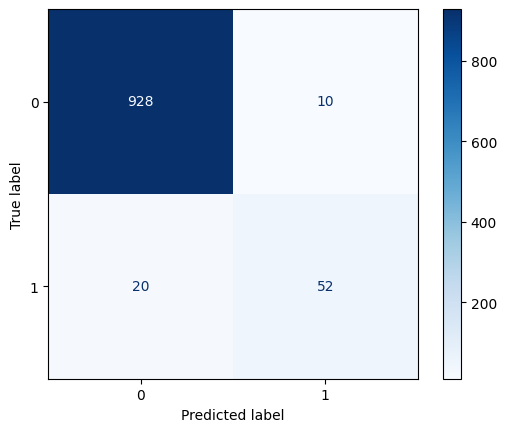

In [284]:
disp = ConfusionMatrixDisplay(cm_esm)
disp.plot(cmap='Blues')
plt.savefig("confusion_matrix_esm.png", dpi=300, bbox_inches='tight')

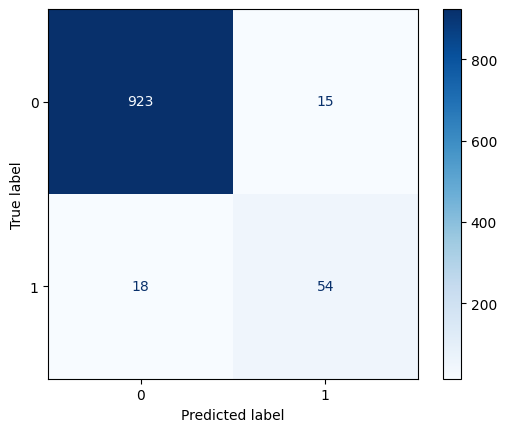

In [285]:
disp = ConfusionMatrixDisplay(cm_tape)
disp.plot(cmap='Blues')
plt.savefig("confusion_matrix_tape.png", dpi=300, bbox_inches='tight')

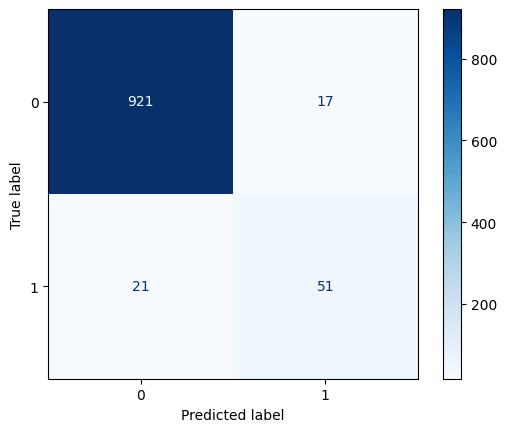

In [286]:
disp = ConfusionMatrixDisplay(cm_rl)
disp.plot(cmap='Blues')
plt.savefig("confusion_matrix_rl.png", dpi=300, bbox_inches='tight')